In [1]:
import sys
print(sys.executable)

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset

print("Libraries loaded successfully!")

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!


In [5]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")
dataset


c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\786\.cache\huggingface\hub\datasets--fancyzhx--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 152406.39 exampl

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [6]:
print("Training Samples:", len(dataset["train"]))
print("Testing Samples:", len(dataset["test"]))

Training Samples: 120000
Testing Samples: 7600


In [7]:
dataset["train"][0]


{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

In [8]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

label_names

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

In [9]:
for i in range(5):
    print("Category:", label_names[dataset["train"][i]["label"]])
    print("News:", dataset["train"][i]["text"])
    print("-" * 80)

Category: Business
News: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
--------------------------------------------------------------------------------
Category: Business
News: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
--------------------------------------------------------------------------------
Category: Business
News: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
--------------------------------------------------------------------------------
Category: Business
News: Iraq Halts O

In [10]:
train_df = pd.DataFrame(dataset["train"])

train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [11]:
print("Shape:", train_df.shape)

Shape: (120000, 2)


In [12]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [13]:
train_df["label"].value_counts()

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

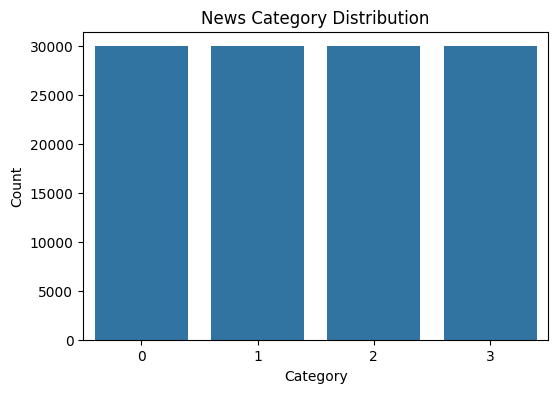

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train_df)

plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [15]:
label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

train_df["category"] = train_df["label"].map(label_map)

train_df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


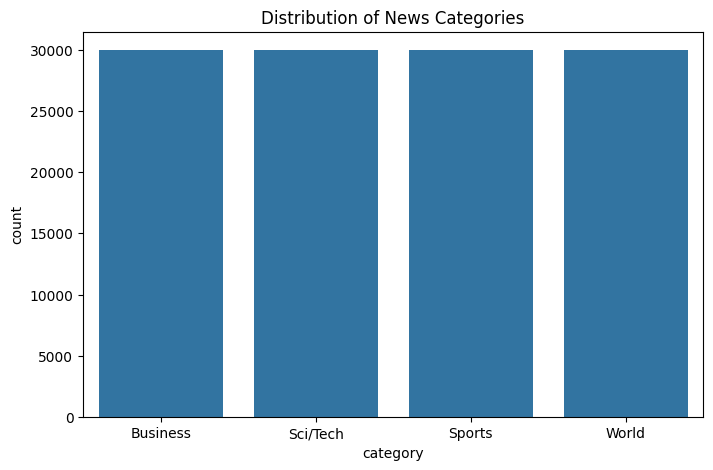

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x="category", data=train_df)

plt.title("Distribution of News Categories")
plt.show()

In [17]:
train_df["text_length"] = train_df["text"].apply(len)

train_df["text_length"].describe()

count    120000.000000
mean        236.477525
std          66.509741
min         100.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: text_length, dtype: float64

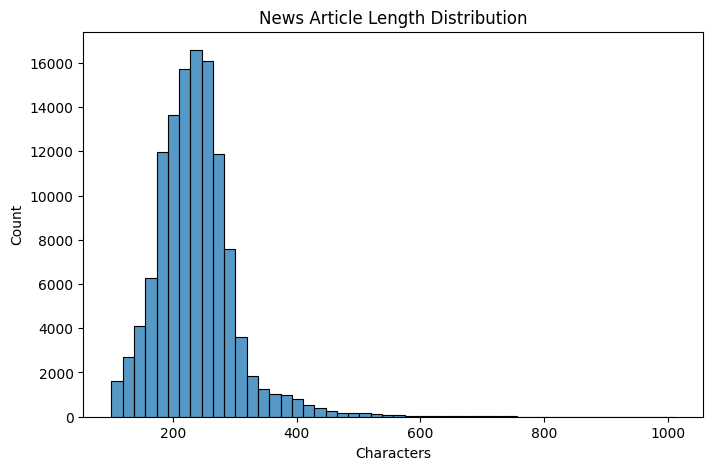

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["text_length"], bins=50)

plt.title("News Article Length Distribution")
plt.xlabel("Characters")
plt.show()

In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\786\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [20]:
sample_text = train_df["text"][0]

tokens = tokenizer(sample_text)

tokens

{'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [21]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [22]:
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 7600/7600 [00:01<00:00, 4058.80 examples/s]


In [23]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [24]:
tokenized_dataset["train"][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2,
 'input_ids': [101,
  2813,
  2358,
  1012,
  6468,
  15020,
  2067,
  2046,
  1996,
  2304,
  1006,
  26665,
  1007,
  26665,
  1011,
  2460,
  1011,
  19041,
  1010,
  2813,
  2395,
  1005,
  1055,
  1040,
  11101,
  2989,
  1032,
  2316,
  1997,
  11087,
  1011,
  22330,
  8713,
  2015,
  1010,
  2024,
  3773,
  2665,
  2153,
  1012,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,

In [25]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

In [26]:
num_labels = 4

In [27]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2192.65it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [28]:
small_train_dataset = tokenized_dataset["train"].shuffle(seed=42).select(range(5000))
small_test_dataset = tokenized_dataset["test"].shuffle(seed=42).select(range(1000))

print(small_train_dataset)
print(small_test_dataset)

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1000
})


In [29]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

In [30]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_news_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_test_dataset,
    compute_metrics=compute_metrics,
)

In [33]:
trainer.train()

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.356700,0.323337,0.907000,0.906922


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


TrainOutput(global_step=625, training_loss=0.41867042770385743, metrics={'train_runtime': 4921.1098, 'train_samples_per_second': 1.016, 'train_steps_per_second': 0.127, 'total_flos': 328894725120000.0, 'train_loss': 0.41867042770385743, 'epoch': 1.0})

In [34]:

eval_results = trainer.evaluate()
eval_results


c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.356700,0.323337,1,0.907000,0.906922


{'eval_loss': 0.3233374357223511,
 'eval_accuracy': 0.907,
 'eval_f1': 0.9069222860539824}

In [35]:
predictions = trainer.predict(small_test_dataset)

pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [36]:
predictions = trainer.predict(small_test_dataset)

pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

c:\Users\786\Desktop\AI-ML-PROJECTS-PHASE2\NewsTopicClassifierBERT\venv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    pred_labels,
    target_names=["World", "Sports", "Business", "Sci/Tech"]
))

              precision    recall  f1-score   support

       World       0.97      0.84      0.90       266
      Sports       0.95      0.99      0.97       246
    Business       0.88      0.87      0.88       246
    Sci/Tech       0.83      0.93      0.88       242

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



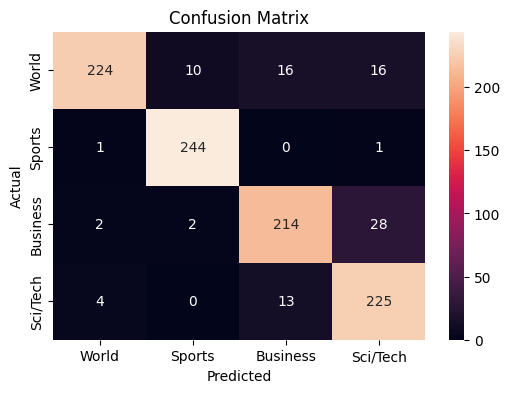

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["World", "Sports", "Business", "Sci/Tech"],
    yticklabels=["World", "Sports", "Business", "Sci/Tech"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
trainer.save_model("./saved_bert_news_model")
tokenizer.save_pretrained("./saved_bert_news_model")

print("Model saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s]

Model saved successfully!


In [49]:
import torch

text = "Federal Reserve raises interest rates"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

print("Prediction:", label_map[prediction])

Prediction: Business


In [50]:
import torch

label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

def predict_news(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    print("News:", text)
    print("Predicted Category:", label_map[prediction])
    print("-" * 50)


predict_news("Pakistan wins T20 series against Australia")
predict_news("Apple launches new AI powered iPhone features")
predict_news("Tesla stock jumps after strong quarterly earnings")
predict_news("United Nations discusses climate change policy")

News: Pakistan wins T20 series against Australia
Predicted Category: Sports
--------------------------------------------------
News: Apple launches new AI powered iPhone features
Predicted Category: Sci/Tech
--------------------------------------------------
News: Tesla stock jumps after strong quarterly earnings
Predicted Category: Business
--------------------------------------------------
News: United Nations discusses climate change policy
Predicted Category: Sci/Tech
--------------------------------------------------
